# Datos Faltantes

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer, KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar el conjunto de datos
diabetes = load_diabetes(as_frame=True)
data = diabetes.data
data['target'] = diabetes.target

In [3]:
data.sample(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
431,0.070769,0.050680,-0.030996,0.021872,-0.037344,-0.047034,0.033914,-0.039493,-0.014960,-0.001078,66.0
106,-0.096328,-0.044642,-0.076264,-0.043542,-0.045599,-0.034821,0.008142,-0.039493,-0.059471,-0.083920,134.0
47,-0.078165,-0.044642,-0.073030,-0.057313,-0.084126,-0.074277,-0.024993,-0.039493,-0.018114,-0.083920,142.0
138,0.034443,0.050680,0.111276,0.076958,-0.031840,-0.033881,-0.021311,-0.002592,0.028020,0.073480,336.0
430,-0.009147,-0.044642,-0.056863,-0.050427,0.021822,0.045345,-0.028674,0.034309,-0.009919,-0.017646,183.0
171,-0.020045,-0.044642,-0.046085,-0.098627,-0.075870,-0.059873,-0.017629,-0.039493,-0.051404,-0.046641,74.0
396,-0.085430,0.050680,-0.030996,-0.022885,-0.063487,-0.054236,0.019187,-0.039493,-0.096435,-0.034215,43.0
155,-0.027310,0.050680,0.060618,0.049415,0.085116,0.086368,-0.002903,0.034309,0.037811,0.048628,186.0
180,-0.038207,0.050680,0.004572,0.035644,-0.011201,0.005889,-0.047082,0.034309,0.016307,-0.001078,107.0
159,-0.005515,-0.044642,0.043373,0.087287,0.013567,0.007141,-0.013948,-0.002592,0.042341,-0.017646,195.0


In [5]:
# Simular valores faltantes
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado:

### 1. ¿Cuántos valores faltantes hay en cada columna?**

In [6]:

data.isnull().sum()

age        0
sex        0
bmi       44
bp        44
s1         0
s2         0
s3         0
s4         0
s5         0
s6         0
target     0
dtype: int64

### 2. Utiliza imputación simple (media) para llenar los valores faltantes de la columna 'bmi'.

In [7]:
bmi_antes = data['bmi'].copy()
data_para_knn = data.copy()

imputer_media = SimpleImputer(strategy='mean')
data['bmi'] = imputer_media.fit_transform(data[['bmi']])

### 3. Utiliza KNNImputer para imputar valores en las columnas 'bmi' y 'bp'. Compara los resultados con los de la imputación simple.

In [8]:
# KNNImputer para 'bmi' y 'bp'
knn_imputer = KNNImputer(n_neighbors=5)
data_knn = data_para_knn.copy()
data_knn[['bmi', 'bp']] = knn_imputer.fit_transform(data_para_knn[['bmi', 'bp']])

# Comparación con imputación simple (media)
comparacion = pd.DataFrame({
    'bmi_imputacion_media': data['bmi'],
    'bmi_knn': data_knn['bmi'],
    'bp_knn': data_knn['bp']
})
comparacion.describe()

,bmi_imputacion_media,bmi_knn,bp_knn
count,442.000000,442.000000,442.000000
mean,-0.000205,0.000213,0.000296
std,0.044583,0.045416,0.046323
min,-0.089197,-0.089197,-0.112399
25%,-0.030996,-0.032073,-0.033213
50%,-0.000817,-0.005128,-0.005670
75%,0.024781,0.030440,0.033053
max,0.160855,0.160855,0.132044


### 4. Genera un histograma comparando los datos antes y después de la imputación en la columna 'bmi'.

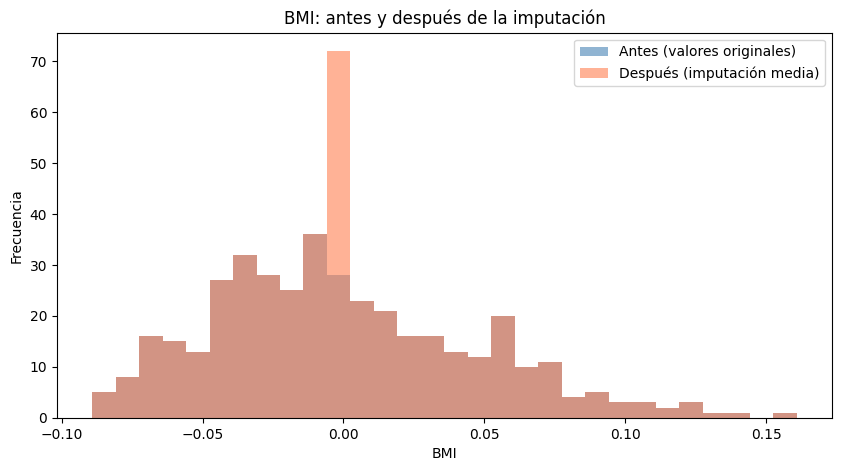

In [9]:
# Histograma: bmi antes y después de la imputación
plt.figure(figsize=(10, 5))
plt.hist(bmi_antes.dropna(), bins=30, alpha=0.6, label='Antes (valores originales)', color='steelblue')
plt.hist(data['bmi'], bins=30, alpha=0.6, label='Después (imputación media)', color='coral')
plt.xlabel('BMI')
plt.ylabel('Frecuencia')
plt.legend()
plt.title('BMI: antes y después de la imputación')
plt.show()